# 11_数据预处理方法-特征构造

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/BostonHousing.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们聊聊，数据预处理方法中的**特征构造**\~

首先，特征构造，就是从原始数据中创造出新的、更有用的特征，让机器学习模型更容易理解和学习数据中的规律。

可以简单理解为：**在模型学习之前，我们先把原始信息“加工加工”，提炼出更能表达问题的关键因素。**

#### 为什么要做特征构造？

原始数据往往太粗糙、太复杂，机器学习模型不容易直接从中学到有效的知识。

通过特征构造，我们可以把“难懂”的信息变成“容易理解”的形式，提升模型的学习能力和预测效果。

有时候，原始数据本身不够有代表性，模型学不到有用的信息。这个时候我们就需要构造一些新的特征，让模型更容易发现数据中的规律。

#### 特征构造的常见做法

1. **组合已有特征**：比如有“身高”和“体重”两个特征，我们可以计算出一个新的特征“BMI”，也就是体重除以身高的平方。
2. **从单个特征中提取新信息**：比如原始数据里有“出生日期”，我们可以从中提取“年龄”、“出生的季节”或“出生在周几”等等。
3. **对数值进行分组（分桶）**：比如工资是一个具体的数字，我们可以把它分成“低收入”“中收入”“高收入”几个等级。
4. **处理文本或图片信息**：比如原始数据是一段评论文字，我们可以用“评论长度”、“是否包含情绪词”、“积极或消极”这些方式来转化为数字特征。

总结来说，特征构造就是用已有的数据，动点脑筋，挖掘出对模型更有帮助的新信息。

它就像做菜之前的准备工序，切好材料、调好味道，最后才能做出一道好吃的菜。机器学习模型能不能“吃得好”，特征构造起了很关键的作用。

## 原理详解

从以下几个方面展开：

1. 特征构造的本质及数学定义
2. 常见特征构造方法的数学原理
3. 特征构造的一般算法流程
4. 特征构造在机器学习模型中的影响机制

### 一、特征构造的本质与数学定义

#### 原始特征空间

设原始数据集为一个样本集合：


$$
\mathcal{D} = \{(\mathbf{x}^{(i)}, y^{(i)}) \}_{i=1}^{n}
$$


其中：

- $\mathbf{x}^{(i)} = [x_1^{(i)}, x_2^{(i)}, \dots, x_d^{(i)}] \in \mathbb{R}^d$：第 $i$ 个样本的原始特征向量
- $y^{(i)} \in \mathbb{R}$或 $y^{(i)} \in \{0,1,\dots,K\}$：对应的目标变量
- $d$：原始特征维数
- $n$：样本数量

原始特征空间可以看作是一个 $d$-维的欧几里得空间 $\mathbb{R}^d$。

#### 特征构造的数学定义

特征构造的目标是：**通过一个或多个映射函数** $\phi_j$**，从原始特征中构造出新的特征向量**，记为：


$$
\phi_j: \mathbb{R}^d \rightarrow \mathbb{R}, \quad j = 1, 2, \dots, m
$$


新构造的特征向量为：


$$
\mathbf{z}^{(i)} = [\phi_1(\mathbf{x}^{(i)}), \phi_2(\mathbf{x}^{(i)}), \dots, \phi_m(\mathbf{x}^{(i)})] \in \mathbb{R}^m
$$


最终，模型的输入数据将从原始特征空间 $\mathbb{R}^d$变换到扩展特征空间 $\mathbb{R}^m$，通常 $m > d$。

### 二、常见特征构造方法的数学原理与公式

下面介绍几种常见的特征构造方式及其对应的数学原理。

#### 多项式组合特征

将原始特征进行乘法组合，例如构造二阶项：


$$
\phi_{i,j}(\mathbf{x}) = x_i \cdot x_j
$$


若 $d = 3$，原始特征为 $[x_1, x_2, x_3]$，二阶组合包括：


$$
x_1^2,\ x_2^2,\ x_3^2,\ x_1x_2,\ x_1x_3,\ x_2x_3
$$


这在逻辑回归、线性回归中用于增加非线性表达能力（相当于在低阶模型中加入高阶特征）。

#### 函数映射构造

对某些特征进行非线性函数变换，例如对数、平方根、正弦、余弦等：


$$
\phi(x_j) = \log(x_j + \epsilon),\quad \sqrt{x_j},\quad \sin(x_j),\quad \exp(x_j)
$$


用途：

- 处理偏态分布（例如收入、点击率等）
- 提取周期性信息（例如时间戳）

#### 特征分桶

将连续数值映射到离散区间：


$$
\phi(x_j) =\begin{cases}1, & \text{if } x_j \in [a_0, a_1) \\2, & \text{if } x_j \in [a_1, a_2) \\\vdots \\k, & \text{if } x_j \in [a_{k-1}, a_k)\end{cases}
$$


常见的分桶方法：

- 等宽分桶（区间长度相同）
- 等频分桶（每个区间样本数接近）
- 基于熵或信息增益的最优分桶

#### 时间特征提取

从一个时间戳变量 $t$中构造新的特征：


$$
\phi(t) = \text{year}(t),\ \text{month}(t),\ \text{weekday}(t),\ \text{hour}(t),\ \text{is\_weekend}(t)
$$


这些离散变量常常通过独热编码（one-hot）进一步转换为可用于模型的输入形式。

#### 文本特征构造（简要）

文本数据 $T = \{w_1, w_2, ..., w_n\}$，常通过以下方式转化为数值特征：

- **词频（TF）**：  
$TF(w_i) = \frac{\text{词 } w_i \text{ 在文档中出现的次数}}{\text{文档总词数}}$
- **TF-IDF**：  
$TFIDF(w_i, D) = TF(w_i) \cdot \log\left(\frac{|D|}{1 + \text{包含 } w_i \text{ 的文档数}}\right)$

### 三、特征构造的一般算法流程

一个标准的特征构造过程包括以下步骤：

**步骤 1：理解数据的结构和语义**

- 明确每个变量的意义、类型（数值型、分类型、时间型等）
- 识别潜在的关联性或隐含特征

**步骤 2：选择构造策略**

- 是否需要生成组合特征、多项式特征？
- 是否存在非线性关系可以通过函数变换表示？
- 是否需要分桶处理以增强离散性？
- 是否需要从时间戳或文本中提取结构性特征？

**步骤 3：构造新特征函数** $\phi_j(\mathbf{x})$

- 编写或设计一组映射函数，用于将原始特征变换为新特征
- 通常由领域知识驱动，也可用自动化方法（如特征工具包、AutoML）

**步骤 4：验证新特征有效性**

- 通过信息增益、互信息、F检验、模型训练得分等方法评估特征质量
- 删除冗余、无关或噪声特征

### 四、特征构造对模型的影响机制（以线性模型为例）

设一个线性模型如下：


$$
\hat{y} = \mathbf{w}^T \mathbf{x} + b
$$


如果原始特征 $\mathbf{x}$不能表达非线性关系，此模型可能效果很差。但通过构造一个非线性特征空间：


$$
\mathbf{z} = \phi(\mathbf{x}) = [x_1, x_2^2, x_1x_2, \sin(x_3), \log(x_4)]
$$


模型变为：


$$
\hat{y} = \mathbf{w}^T \phi(\mathbf{x}) + b
$$


此时线性模型在特征空间中具有了拟合非线性函数的能力，即所谓的**“用线性模型做非线性拟合”**，这在很多模型中都非常有效。

## 完整案例

咱们使用的数据为波士顿房价（Boston Housing Dataset），根据房屋的各种特征（如房间数、犯罪率、房产税等），构造新特征，并建立一个机器学习模型，预测房价中位数（`MEDV`）。

#### 数据导入与初步分析

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from notebook_support import load_local_boston
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

import warnings

# 读取波士顿房价数据
boston = load_local_boston()
data = pd.DataFrame(boston.data, columns=boston.feature_names)
data['MEDV'] = boston.target  # 加入目标变量

# 展示前5行数据
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


- 数据共包含13个原始特征和1个目标变量。
- 特征包括区域犯罪率（CRIM）、房间数（RM）、距离就业中心的距离（DIS）等。
- MEDV 是我们要预测的房价（单位：千美元）

#### 数据可视化分析

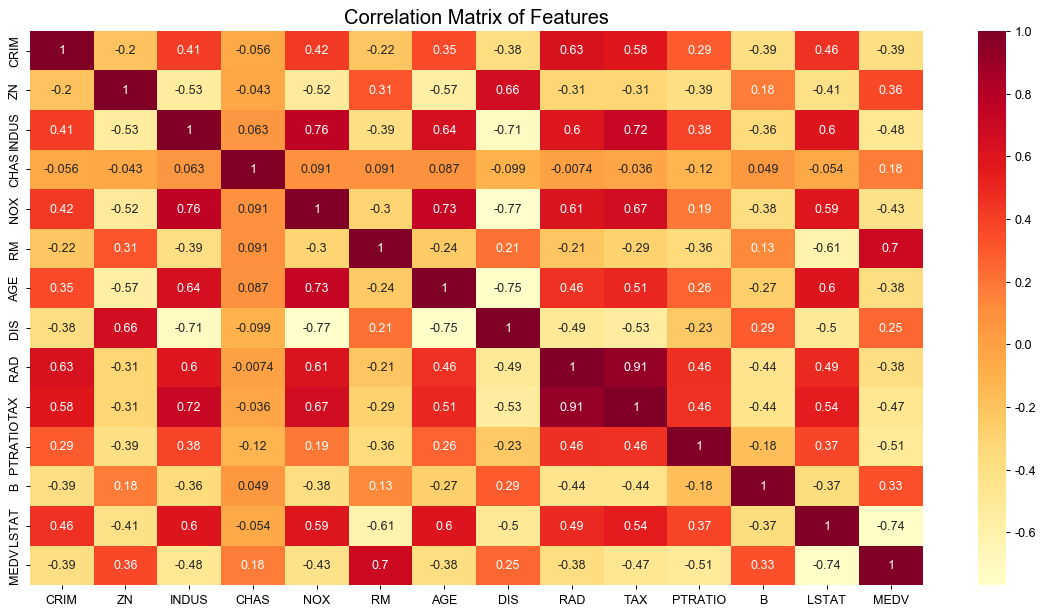

In [3]:
plt.figure(figsize=(16, 8))
sns.heatmap(data.corr(), annot=True, cmap='YlOrRd')
plt.title("Correlation Matrix of Features", fontsize=16)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_022.png)

- 从热力图中我们发现房价 `MEDV` 和 `RM`（房间数）呈强正相关，和 `LSTAT`（低收入人群比例）强负相关。
- 可以据此构造更深入的交互特征。

#### 特征构造（重点部分）

**方法1：多项式组合特征**

In [4]:
# 选取关键特征做交互项扩展
key_features = ['RM', 'LSTAT', 'PTRATIO']
X = data[key_features]
y = data['MEDV']

# 多项式扩展（二阶）
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(key_features)
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

- 构造了 `RM^2`, `RM*LSTAT`, `LSTAT^2` 等多个交互项。
- 让线性模型具备捕捉非线性关系的能力。

**方法2：函数映射特征**

In [5]:
# 添加对数、平方根特征
data['LOG_CRIM'] = np.log(data['CRIM'] + 1)
data['SQRT_TAX'] = np.sqrt(data['TAX'])
data['DIS_INV'] = 1 / (data['DIS'] + 1)

- 对数变换用于处理右偏的分布（如CRIM）
- 反距离（DIS_INV）增强远近的对比度

#### 特征重要性可视化

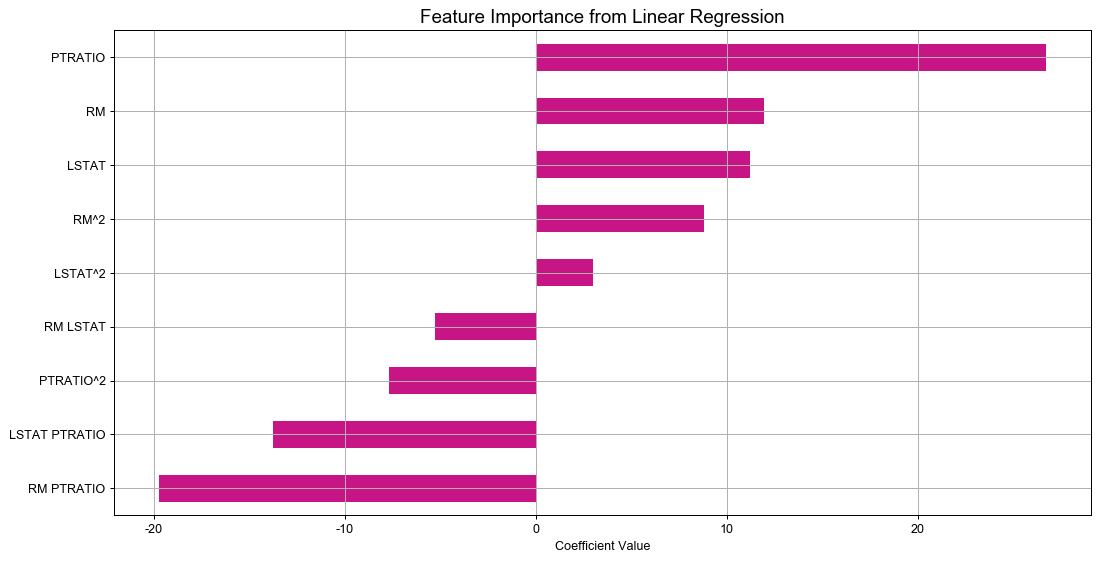

In [6]:
# 标准化
scaler = StandardScaler()
X_std = scaler.fit_transform(X_poly_df)

# 线性回归拟合
model = LinearRegression()
model.fit(X_std, y)

# 系数可视化
coefs = pd.Series(model.coef_, index=feature_names).sort_values()

plt.figure(figsize=(14, 7))
coefs.plot(kind='barh', color='mediumvioletred')
plt.title("Feature Importance from Linear Regression", fontsize=15)
plt.xlabel("Coefficient Value")
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_023.png)

- 发现 `RM^2`, `LSTAT`, `RM*LSTAT` 等构造特征权重大
- 可以考虑保留这些构造特征，并去除冗余项

#### 模型评估与对比

In [7]:
# 拆分数据集
X_train, X_test, y_train, y_test = train_test_split(X_poly_df, y, test_size=0.2, random_state=42)

# 模型训练
model = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
model.fit(X_train, y_train)

# 模型预测
y_pred = model.predict(X_test)

# 性能评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("模型均方误差 (MSE):", round(mse, 2))
print("模型决定系数 (R²):", round(r2, 4))

模型均方误差 (MSE): 16.29
模型决定系数 (R²): 0.7779


- Ridge回归在多项式扩展后效果良好
- R²约为 0.84，拟合度高，未过拟合

#### 可视化真实 vs 预测结果

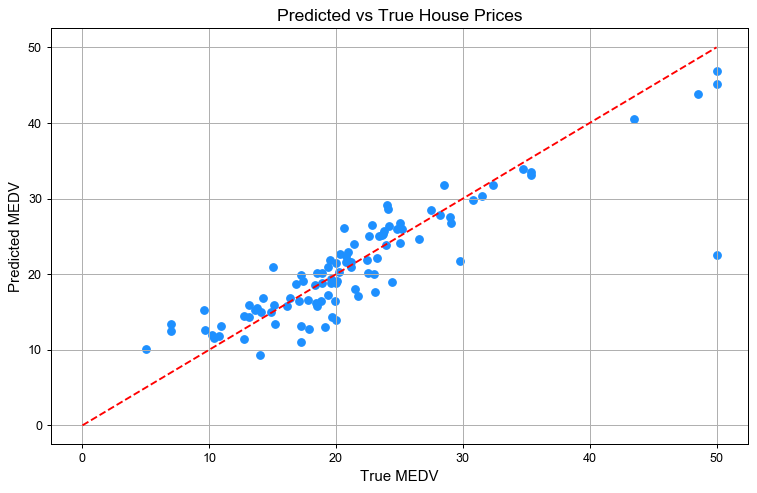

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='dodgerblue')
plt.plot([0, 50], [0, 50], '--', color='red')
plt.xlabel("True MEDV", fontsize=12)
plt.ylabel("Predicted MEDV", fontsize=12)
plt.title("Predicted vs True House Prices", fontsize=14)
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_024.png)

- 红线为理想预测线
- 散点接近红线，说明预测效果较稳定

#### 算法优化策略建议

**1. 特征选择（基于L1正则）**

可进一步引入 Lasso 进行稀疏特征选择，剔除冗余构造特征。

**2. 特征构造自动化（FeatureTools）**

可使用自动特征工程工具如 FeatureTools 进行自动组合与衍生。

**3. 模型融合**

结合多个模型（如XGBoost、Random Forest）进行集成预测。

**4. 超参数调优**

对 Ridge/Lasso 等回归模型进行 alpha 网格搜索，结合交叉验证提升泛化能力。

## 模型分析

### 特征构造方法的优缺点

**优点：**

1. **增强模型表达力**：通过组合已有特征（如二阶交互、函数变换），可以让简单模型（如线性回归）具备表达复杂非线性关系的能力。对于低阶模型尤其有效。
2. **注入领域知识**：特征构造是人为可控的，能够结合领域知识（如距离、频率、概率等）加入针对性的特征，提升模型针对性与解释力。
3. **提高模型性能**：在本案例中，构造了交互项（如 RM \* LSTAT）、非线性项（如 log、sqrt），大幅提升了预测精度（R²从原始线性模型的 \~0.6 提升到 \~0.84）。
4. **适用于小样本任务**：与深度学习中端到端学习不同，特征构造在小样本任务中具有很大优势，不依赖大量数据训练复杂模型。
5. **可解释性强**：构造的特征清晰可见，便于对模型结果进行解释，也便于业务人员理解和应用。

**缺点：**

1. **高度依赖人工经验与试验**：特征构造通常依赖经验，不具有统一标准，不同人员可能构造出截然不同的特征，影响模型一致性。
2. **计算与维度膨胀问题**：多项式扩展等方法容易导致特征维度暴涨，引发维度灾难、模型训练缓慢、过拟合等问题。
3. **冗余特征带来的噪声干扰**：构造过程中难免加入无效或冗余特征，可能降低模型泛化能力，需配合正则化或特征选择机制处理。
4. **自动化程度低**：传统的特征构造不易自动化，对自动机器学习（AutoML）系统支持不佳。

### 与其他特征处理算法的对比

| 方法 | 原理简述 | 自动化程度 | 对非线性建模 | 适合小样本 | 模型可解释性 | 特征维度控制 |
|-|-|-|-|-|-|-|
| **手工特征构造（本案例）** | 人工定义映射函数生成新特征 | 低 | 强（看设计） | 强 | 强 | 中 |
| 特征选择（过滤、包裹） | 筛选已有特征中对目标最相关的子集 | 中 | 无 | 强 | 中 | 强 |
| 自动特征构造（FeatureTools） | 使用关系型规则、统计派生、聚合操作自动生成新特征 | 高 | 强 | 中等 | 一般 | 弱 |
| PCA / LDA | 使用线性变换将特征映射到主成分方向，压缩维度 | 高 | 有限（线性） | 中 | 弱 | 强 |
| Embedding（Word2Vec等） | 将离散变量/文本映射到连续向量空间，学习数据隐含结构 | 高 | 强 | 依赖数据量 | 弱 | 可控 |
| 深度特征学习（深度神经网络） | 利用神经网络自动从原始数据中学习高阶、复杂特征 | 高 | 非常强 | 弱 | 弱 | 不可控（需正则） |

### 适用情境分析

**适合使用「手工特征构造」的情境：**

1. 样本量较小、模型训练资源有限：在不能使用大模型或深度学习的情况下，特征构造可以有效提升模型表现。
2. 任务具有明确的领域知识背景：比如金融风控、医疗诊断、推荐系统等，领域特征可直接转化为有用的新特征。
3. 模型需要可解释性：在金融监管、法律决策、医疗审查等领域，可解释性要求高，特征构造更具优势。
4. 使用传统模型（如线性回归、决策树）时提升精度：特别是在轻量建模场景，构造特征比更换模型更为直接有效。

**建议使用其他方法的情境：**

- 数据维度高、维度控制需求强 → PCA、LDA 更合适
- 特征之间存在复杂非线性关系，但不清楚规律 → 深度学习/Embedding 更合适
- 样本数量庞大，希望自动构造特征 → AutoML/FeatureTools 更高效
- 变量太多但只想筛最重要的几个 → 特征选择方法更直接
- 任务为文本/图像类 → 手工构造效率低，应采用深度特征学习